## Optimal debt problem

\begin{align*}
V(\boldsymbol{\zeta},b;\boldsymbol{\mathcal{M}}) = &\max_{\{c^{T},b^{\prime}\}}{\mathcal{U}(\mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h}(\boldsymbol{\zeta},b,\boldsymbol{\mathcal{M}},\bar{w})))) + \beta\mathbb{E}[V(\boldsymbol{\zeta}^{\prime},b^{\prime};\boldsymbol{\mathcal{M}}^{\prime})]}\\[0.2cm]
& \text{s.t. }c^{T} = y^{T} %- \kappa i_{t}^{l}w_{t}h_{t} 
%+ q(b^{\prime} - (1-\theta)b) - (\theta + \delta(1-\theta))b\\[0.2cm]
+ qb^{\prime} - (\theta+(1-\theta)(q+\delta))b\\[0.2cm]
& \phantom{\text{s.t. }}\mathfrak{h}(\boldsymbol{\zeta},b,\boldsymbol{\mathcal{M}},\bar{w}) = \min\left\{\frac{d^{*}+(q(1-\chi^{CB})+q^{CB}\chi^{CB})\psi b}{\kappa\bar{w}},\bar{h}\right\}
\end{align*}

### Functional forms ("Model")

\begin{gather*}
c^{T}(b,b^{\prime},y^{T},q;\theta,\delta) = y^{T} + qb^{\prime} - (\theta + (q+\delta)(1-\theta))b\\[0.4cm]
\mathfrak{h}(b,q,s;\bar{h},d^{*},q^{CB},\chi^{CB},\psi,\kappa,\bar{w}) = \min\left\{\frac{d^{*}+(q(1-\chi^{CB})+q^{CB}\chi^{CB})\psi b}{\kappa\bar{w}},\bar{h}\right\}\\[0.4cm]
%\mathfrak{h}_{b}(\mathfrak{h},q,s;\bar{h},q^{CB},\chi^{CB},\psi,\kappa,\bar{w}) = 
%\begin{cases}
%0 & \text{if }\mathfrak{h}=\bar{h}\\[0.3cm]
%\frac{(q(1-\chi^{CB})+q^{CB}\chi^{CB})\psi}{\kappa\bar{w}} & \text{if }\mathfrak{h}<\bar{h}
%\end{cases}\\[0.6cm]
\mathcal{F}(\mathfrak{h};\alpha) = \mathfrak{h}^{\alpha}\\[0.3cm]
%\mathcal{F}_{\mathfrak{h}}(\mathfrak{h};\alpha) = \alpha\mathfrak{h}^{\alpha-1}\\[0.3cm]
\mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h});\omega,\xi) = \left(\omega(c^{T})^{1-\frac{1}{\xi}} + (1-\omega)\mathcal{F}(\mathfrak{h})^{1-\frac{1}{\xi}}\right)^{\frac{1}{1-\frac{1}{\xi}}}\\[0.3cm]
%\mathcal{C}_{T}(c^{T},\mathcal{F}(\mathfrak{h});\omega,\xi) = \mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h}))^{\frac{1}{1-\frac{1}{\xi}}-1}\omega(c^{T})^{-\frac{1}{\xi}}\\[0.3cm]
%\mathcal{C}_{NT}(c^{T},\mathcal{F}(\mathfrak{h});\omega,\xi) = \mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h}))^{\frac{1}{1-\frac{1}{\xi}}-1}(1-\omega)\mathcal{F}(\mathfrak{h})^{-\frac{1}{\xi}}\\[0.3cm]
%\mathcal{U}_{\mathcal{C}}(\mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h}));\sigma) = \mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h}))^{-\sigma}\\[0.3cm]
\mathcal{U}(\mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h}));\sigma) = \frac{\mathcal{C}(c^{T},\mathcal{F}(\mathfrak{h}))^{1-\sigma} - 1}{1-\sigma}
\end{gather*}

In [1]:
using LaTeXStrings, Parameters, QuantEcon, Random, LinearAlgebra
using Statistics, Plots, LaTeXStrings, JLD
Random.seed!(1234)
rng = MersenneTwister(1234)
include("VARdiscretization.jl")
Threads.nthreads()

8

* Instantaneous utility and production function of the non-tradable producer:

In [2]:
# CRRA instantaneous utility function
u(mod, c) = (c^(1 - mod.σ) - 1)/(1 - mod.σ)
# Production function
F(mod, h) = h^(mod.α)

F (generic function with 1 method)

* Tradable consumption and composite consumption

In [3]:
# Tradable good resource constraint
cᵀ(mod, ζ, b, b₊) = ζ[1] + ζ[2]*b₊ - (mod.θ + (1-mod.θ)*(ζ[2]+mod.δ))*b
# Composite consumption
c(mod, cᵀ, F) = (mod.ω*(cᵀ)^(1-(1/mod.ξ)) + (1-mod.ω)*F^(1-(1/mod.ξ)))^(1/(1-(1/mod.ξ)))

c (generic function with 1 method)

* Equilibrium labour demand:

In [4]:
# Equilibrium labour demand
h(mod, ζ, b, qCB, χ) = min((mod.d+(ζ[2]*(1-χ)+qCB*χ)*mod.ψ*b)/(mod.κ*mod.wbar),
                            mod.hbar)

h (generic function with 1 method)

* Unconventional monetary policy "rule"

    \begin{equation*}
        \color{red}\chi^{CB} = 
        \begin{cases}
        \chi^{*} & \text{if }\frac{q}{\bar{q}}<\text{threshold}\\[0.3cm]
        0 & \text{otherwise}
        \end{cases} 
    \end{equation*}

In [5]:
function UMPfactor(mod, ζ, UMPpolicy)
    if UMPpolicy == false
        UMPfactor = zero(mod.chistar)
    elseif UMPpolicy == true
        s = ζ[2]/mod.qbar 
        if s < 1 && abs(s-1) ≥ mod.threshold
            UMPfactor = mod.chistar
        else
            UMPfactor = zero(mod.chistar)
        end
    end

    return UMPfactor
end

UMPfactor (generic function with 1 method)

#### Monetary Union QE model definition

- Solving for $\boldsymbol{\zeta}_t = [y_t^{T},q_t]$ from discretised exogenous states from VAR model summarised by loaded matrices $\{\mathbf{A},\boldsymbol{\Sigma}\}$: 

    $$
        {\color{blue}y_t^{T} = \exp{(\ln{(y_t^{T})})}}\\[0.5cm]
        \ln{(s_t)} \equiv \ln{\left(\frac{1/q_t}{1/\bar{q}}\right)} = \ln{\left(\frac{1+i_{t|1/\theta}}{1/\bar{q}}\right)} = \ln{\left(\frac{1+i_{t|1/\theta}}{1+\bar{i}_{1/\theta}}\right)}\\[0.5cm]
        \color{blue}q_t = \frac{\bar{q}}{\exp{(\ln{(s_t)})}}\color{gray} = \frac{(1/1+\bar{i})}{\exp{(\ln{(s_t)})}}
    $$

    $VAR(1)$ models of the correlated exogenous states are estimated in file [VAR_estimation.ipynb](./VAR_estimation.ipynb)

In [6]:
function QEMUmodel(;β = 0.985,
                    σ = 2.0,
                    ξ = 0.5,
                    ω = 0.26,
                    α = 0.75,
                    hbar = 1,
                    ψ = 0.33,
                    κ = 1.0,
                    θ = 0.05,
                    istar = 0.011,
                    b_min = 0.0,
                    b_max = 1.2,
                    nb = 200,
                    GridSize = [21,11],
                    chistar = 0.2,
                    u_lr = 0.12,
                    l_lr = 0.48,
                    b_lr = 0.49,
                    wbar = l_lr/(κ*(1-u_lr)))

            # No-risk price of the random maturity bond 
            # qbar = (θ+(1-θ)*δ)/(istar+θ)
            qbar = 1/(1+istar)
            # From value of qbar calibrate δ
            δ = ((qbar*istar+θ)-θ)/(1-θ)

            # Calibrate d from long run outstanding debt
            # l = total labour rem. (% GDP) and the assumed value of γ
            d = l_lr - ψ*b_lr

            # Calibrate wbar from l = total labour rem. (% GDP)
            # and long run unemployment rate u


            # Grid for Sovereign debt
            b_grid = collect(range(b_min, b_max, length = nb)) 

            # Loading matrices from VAR of correlated exogenous states
            A_dict = load("./data/A_Spain.jld")
            Sigma_dict = load("./data/Sigma_Spain.jld")
            A = get(A_dict, "A_Spain", 1)
            Σ = get(Sigma_dict, "Sigma_Spain", 1)
            sd_xstates = sqrt.(diag(solve_discrete_lyapunov(A,Σ)))
            
            # Determination of threshold for "targeted" unconventional MP
            threshold = sd_xstates[2]

            # Grid for exogenous states
            mc = tpm(A, Σ, GridSize, trim = true)
            nxs = size(mc.state_values,1)
            # Initializing exogenous states
            xstates = Array{AbstractVector}(undef, nxs)
            #qCB = zeros(nxs)
            # Computing exogenous states yᵀ,q and qCB from initial grid  
            Threads.@threads for i in 1:nxs
                xstates[i] = [exp(mc.state_values[i,1]),
                              qbar/exp(mc.state_values[i,2])]
            #    qCB[i] = 1.1*xstates[i][2]
            end

            # Transition probability matrix of exogenous states
            Π = mc.Π

            #Initialize value functions and debt policy (index)
            V = zeros(nxs,nb)
            Vᴾ = similar(V)
            index_policy_b⁺ = similar(V)
            index_policy_b⁺ᴾ = similar(V)

            return (β = β, σ = σ, ξ = ξ, ω = ω, α = α, ψ = ψ, κ = κ, 
                    wbar = wbar, hbar = hbar, d = d, θ = θ, δ = δ, 
                    istar = istar, qbar = qbar, b_min = b_min, b_max = b_max,
                    nb = nb, GridSize = GridSize, chistar = chistar, #qCB = qCB,
                    threshold = threshold, b_grid = b_grid, xstates = xstates,
                    sd_xstates = sd_xstates, Π = Π, V = V, Vᴾ = Vᴾ,
                    index_policy_b⁺ = index_policy_b⁺, 
                    index_policy_b⁺ᴾ = index_policy_b⁺ᴾ)
end

QEMUmodel (generic function with 1 method)

### Value Function Iteration

\begin{align*}
\color{red}V(\boldsymbol{\zeta},b;\boldsymbol{\mathcal{M}}) = &\color{red}\max_{b^{\prime}}{\;\mathcal{U}(\mathcal{C}(y^{T}+ qb^{\prime}-(\theta+(1-\theta)(q+\delta))b,\mathcal{F}(\mathfrak{h}(\boldsymbol{\zeta},b,\boldsymbol{\mathcal{M}},\bar{w}))))+ \beta\mathbb{E}[V(\boldsymbol{\zeta}^{\prime},b^{\prime};\boldsymbol{\mathcal{M}}^{\prime})]}\\[0.3cm]
&\color{red}\text{s.t. }\;\;\;\mathfrak{h}(\boldsymbol{\zeta},b,\boldsymbol{\mathcal{M}},\bar{w}) = \min\left\{\frac{d^{*}+(q(1-\chi^{CB})+q^{CB}\chi^{CB})\psi b}{\kappa\bar{w}},\bar{h}\right\}
\end{align*}

In [7]:
function BellmanOperator!(mod, EV, UMPpolicy)
    
    # Unpacking
    @unpack β, σ, ξ, ω, α, ψ, κ, wbar, hbar, θ, δ = mod
    @unpack qbar, d, nb, b_grid, xstates, Π, V, Vᴾ = mod
    @unpack index_policy_b⁺, index_policy_b⁺ᴾ, sd_xstates =mod
    @unpack chistar, threshold = mod

    if UMPpolicy == false
        V⁺ = mod.V
        index_policy_b⁺⁺ = mod.index_policy_b⁺
    elseif UMPpolicy == true
        V⁺ = mod.Vᴾ
        index_policy_b⁺⁺ = mod.index_policy_b⁺ᴾ
    end

    Threads.@sync for (is, ζ) in enumerate(mod.xstates)
        
        qCB = 1.1*ζ[2]
        χstar = UMPfactor(mod, ζ, UMPpolicy)

        Threads.@spawn for (ib, b) in enumerate(mod.b_grid) 
            
            current_max = -1e14
            index_policy = 0
            h⁻ = h(mod,ζ,b,qCB,χstar)
            cᴺ = F(mod,h⁻)

            for (ib⁺, b₊) in enumerate(mod.b_grid) 
                cᵀ⁻ = cᵀ(mod,ζ,b,b₊)
                c⁻  = c(mod,cᵀ⁻,cᴺ)
                m = u(mod,c⁻) + β*EV[is,ib⁺]

                if m > current_max
                    current_max = m
                    index_policy = ib⁺
                end
            end

            # Update value function
            V⁺[is,ib] = current_max
            index_policy_b⁺⁺[is,ib] = index_policy
            
        end
    end
end

BellmanOperator! (generic function with 1 method)

In [8]:
function VFI!(mod; tol = 1e-8, maxit = 10000, UMPpolicy = false)
    
    # Unpacking
    @unpack β, σ, ξ, ω, α, ψ, κ, wbar, hbar, θ, δ = mod
    @unpack qbar, d, nb, b_grid, xstates, Π, V, Vᴾ = mod
    @unpack index_policy_b⁺, index_policy_b⁺ᴾ, sd_xstates =mod
    @unpack chistar, threshold = mod
    
    if UMPpolicy == false
        V⁺ = mod.V
    elseif UMPpolicy == true
        V⁺ = mod.Vᴾ
    end

    # Iteration items
    it = 0
    dist = 10.

    # Allocate memory for Update
    V_new = similar(V⁺)
    EV = similar(V⁺)

    while dist > tol && it < maxit
        it += 1

        # Compute expectations
        #copyto!(V_new, mod.V)
        #EV = mod.Π*mod.V
        copyto!(V_new, V⁺)
        EV = mod.Π*V⁺
        
        # Updating through Bellman Operator
        BellmanOperator!(mod, EV, UMPpolicy)

        # Distance assessment
        dist = maximum(abs(vx - vy) for (vx, vy) in zip(V_new, V⁺))

        # Print number of iteration and distance value every 25 iterations
        if it % 25 == 0
            println("Finished iteration $(it) with dist of $(dist)")
        end
    end
end

VFI! (generic function with 1 method)

In [9]:
mod_spain = QEMUmodel(b_max=1.0, GridSize = [31,16], wbar = 0.75)

(β = 0.985, σ = 2.0, ξ = 0.5, ω = 0.26, α = 0.75, ψ = 0.33, κ = 1.0, wbar = 0.75, hbar = 1, d = 0.31829999999999997, θ = 0.05, δ = 0.011452964756103913, istar = 0.011, qbar = 0.9891196834817014, b_min = 0.0, b_max = 1.0, nb = 200, GridSize = [31, 16], chistar = 0.2, threshold = 0.00493511354491852, b_grid = [0.0, 0.005025125628140704, 0.010050251256281407, 0.01507537688442211, 0.020100502512562814, 0.02512562814070352, 0.03015075376884422, 0.035175879396984924, 0.04020100502512563, 0.04522613065326633  …  0.9547738693467337, 0.9597989949748744, 0.964824120603015, 0.9698492462311558, 0.9748743718592965, 0.9798994974874372, 0.9849246231155779, 0.9899497487437185, 0.9949748743718593, 1.0], xstates = AbstractVector[[0.9580318945883273, 1.0046771632165763], [0.9655292349195537, 1.0046771632165763], [0.9692998786536136, 1.0046771632165763], [0.9730852477358609, 1.0046771632165763], [0.9768853996726246, 1.0046771632165763], [0.9807003921948108, 1.0046771632165763], [0.98453028325878, 1.004677

In [10]:
mod_spain.V

477×200 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱            ⋮                   
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

In [11]:
VFI!(mod_spain)
mod_spain.V

Finished iteration 25 with dist of 289.11903535742385
Finished iteration 50 with dist of 184.34528336428775
Finished iteration 75 with dist of 125.94012014471082
Finished iteration 100 with dist of 86.30677327705052
Finished iteration 125 with dist of 59.14932369852977
Finished iteration 150 with dist of 40.53736638519331
Finished iteration 175 with dist of 27.781858298320003
Finished iteration 200 with dist of 19.040004833004787
Finished iteration 225 with dist of 13.048867363664613
Finished iteration 250 with dist of 8.94290421500773
Finished iteration 275 with dist of 6.128925489854737
Finished iteration 300 with dist of 4.200394721563498
Finished iteration 325 with dist of 2.8786964119790355
Finished iteration 350 with dist of 1.972884355327551
Finished iteration 375 with dist of 1.3520955746862455
Finished iteration 400 with dist of 0.9266445030807517
Finished iteration 425 with dist of 0.6350660790412803
Finished iteration 450 with dist of 0.4352358681317128
Finished iteration 47

477×200 Matrix{Float64}:
 26410.5  26410.5  26410.5  26410.5  …  26573.7  26568.4  26563.5  26558.9
 27328.3  27328.3  27328.3  27328.3     27328.7  27328.7  27328.7  27328.7
 27423.9  27423.9  27423.9  27423.9     28023.7  27955.5  27901.0  27856.5
 29052.8  29052.8  29052.8  29052.8     29053.3  29053.3  29053.3  29053.3
 28626.9  28626.9  28626.9  28626.9     28627.4  28627.4  28627.4  28627.4
 28535.5  28535.5  28535.5  28535.5  …  28535.9  28535.9  28535.9  28535.9
 30771.4  30771.4  30771.4  30771.4     31427.9  31324.5  31245.8  31183.9
 29790.5  29790.5  29790.5  29790.5     29806.3  29800.7  29795.4  29790.9
 33752.5  33752.5  33752.5  33752.5     33752.9  33752.9  33752.9  33752.9
 34082.8  34082.8  34082.8  34082.8     34083.2  34083.2  34083.2  34083.2
     ⋮                               ⋱                             
 22697.7  22697.7  22697.7  22697.7     22698.2  22698.2  22698.2  22698.2
 22248.1  22248.1  22248.1  22248.1     22248.5  22248.5  22248.5  22248.5
 21934.

In [13]:
mod_spain.V

477×200 Matrix{Float64}:
 26410.5  26410.5  26410.5  26410.5  …  26573.7  26568.4  26563.5  26558.9
 27328.3  27328.3  27328.3  27328.3     27328.7  27328.7  27328.7  27328.7
 27423.9  27423.9  27423.9  27423.9     28023.7  27955.5  27901.0  27856.5
 29052.8  29052.8  29052.8  29052.8     29053.3  29053.3  29053.3  29053.3
 28626.9  28626.9  28626.9  28626.9     28627.4  28627.4  28627.4  28627.4
 28535.5  28535.5  28535.5  28535.5  …  28535.9  28535.9  28535.9  28535.9
 30771.4  30771.4  30771.4  30771.4     31427.9  31324.5  31245.8  31183.9
 29790.5  29790.5  29790.5  29790.5     29806.3  29800.7  29795.4  29790.9
 33752.5  33752.5  33752.5  33752.5     33752.9  33752.9  33752.9  33752.9
 34082.8  34082.8  34082.8  34082.8     34083.2  34083.2  34083.2  34083.2
     ⋮                               ⋱                             
 22697.7  22697.7  22697.7  22697.7     22698.2  22698.2  22698.2  22698.2
 22248.1  22248.1  22248.1  22248.1     22248.5  22248.5  22248.5  22248.5
 21934.

In [11]:
VFI!(mod_spain, UMPpolicy = true)
mod_spain.Vᴾ

Finished iteration 25 with dist of 292.21822868176423


Finished iteration 50 with dist of 186.93769407706714


Finished iteration 75 with dist of 127.74896798453847


Finished iteration 100 with dist of 87.54698919751172


Finished iteration 125 with dist of 59.999274998164765


...

Finished iteration 1525 with dist of 3.882814780808985e-8


Finished iteration 1550 with dist of 2.663000486791134e-8


Finished iteration 1575 with dist of 1.8259015632793307e-8


Finished iteration 1600 with dist of 1.2521923054009676e-8


469×200 Matrix{Float64}:
 30645.3  30645.3  30645.3  30645.3  …  31592.9  31438.4  31327.2  31243.4
 26653.2  26653.2  26653.2  26653.2     26653.6  26653.6  26653.6  26653.6
 27300.6  27300.6  27300.6  27300.6     27808.2  27740.0  27685.5  27640.9
 29371.8  29371.8  29371.8  29371.8     29500.5  29495.8  29491.4  29487.2
 31112.1  31112.1  31112.1  31112.1     31112.6  31112.6  31112.6  31112.6
 30920.6  30920.6  30920.6  30920.6  …  30921.0  30921.0  30921.0  30921.0
 35403.3  35403.3  35403.3  35403.3     35403.7  35403.7  35403.7  35403.7
 32125.4  32125.4  32125.4  32125.4     32210.2  32204.6  32199.3  32194.4
 33291.4  33291.4  33291.4  33291.4     33291.8  33291.8  33291.8  33291.8
 39139.5  39139.5  39139.5  39139.5     39139.9  39139.9  39139.9  39139.9
     ⋮                               ⋱                             
 23647.6  23647.6  23647.6  23647.6  …  23648.0  23648.0  23648.0  23648.0
 22720.3  22720.3  22720.3  22720.3     22720.7  22720.7  22720.7  22720.7
 22685.

In [12]:
mod_spain.V

469×200 Matrix{Float64}:
 30645.3  30645.3  30645.3  30645.3  …  31592.8  31438.3  31327.1  31243.3
 26653.1  26653.1  26653.1  26653.1     26653.5  26653.5  26653.5  26653.5
 27300.6  27300.6  27300.6  27300.6     27808.1  27739.9  27685.4  27640.8
 29371.7  29371.7  29371.7  29371.7     29500.5  29495.7  29491.3  29487.1
 31112.1  31112.1  31112.1  31112.1     31112.5  31112.5  31112.5  31112.5
 30920.5  30920.5  30920.5  30920.5  …  30921.0  30921.0  30921.0  30921.0
 35403.2  35403.2  35403.2  35403.2     35403.6  35403.6  35403.6  35403.6
 32125.3  32125.3  32125.3  32125.4     32210.1  32204.5  32199.2  32194.3
 33291.3  33291.3  33291.3  33291.3     33291.7  33291.7  33291.7  33291.7
 39139.4  39139.4  39139.4  39139.4     39139.9  39139.9  39139.9  39139.9
     ⋮                               ⋱                             
 23647.5  23647.5  23647.5  23647.5  …  23647.9  23647.9  23647.9  23647.9
 22720.2  22720.2  22720.2  22720.2     22720.6  22720.6  22720.6  22720.6
 22685.

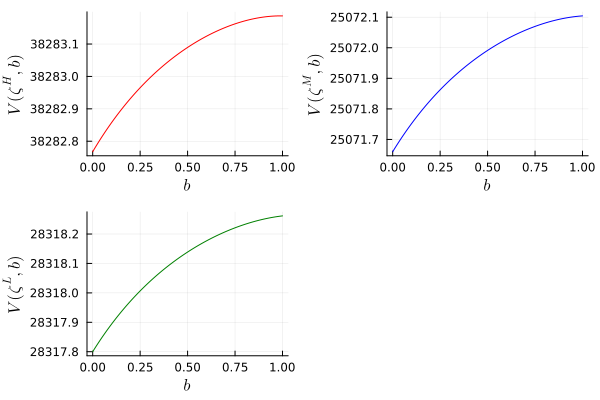

In [13]:
# Value function
V = mod_spain.V 
ζ = norm.(mod_spain.xstates)
ζᴹ = mean(ζ)
iζᴴ, iζᴸ = findmin(ζ)[2], findmax(ζ)[2]
iζᴹ = searchsortedfirst(ζ,ζᴹ)


Vhigh = plot(mod_spain.b_grid, V[iζᴴ,:], #label = L"\zeta^H",
             lc = :red, xlabel = L"b", ylabel = L"V(\zeta^H,b)")
Vmean = plot(mod_spain.b_grid, V[iζᴹ,:], #label = L"\zeta^M",
             lc = :blue, xlabel = L"b", ylabel = L"V(\zeta^M,b)")             
Vlow = plot(mod_spain.b_grid, V[iζᴸ,:], #label = L"\zeta^L",
            lc = :green, xlabel = L"b", ylabel = L"V(\zeta^L,b)")

plot(Vhigh, Vmean, Vlow, legend = false)

In [14]:
x = sort(ζ)
y = mod_spain_noUMP.b_grid
z = vec(sort(hcat(ζ,mod_spain_noUMP.V), dims = 1)[:,2:end])
#contour(y, x, z)
surface(y, x, z)

UndefVarError: UndefVarError: mod_spain_noUMP not defined

### Simulation

In [15]:
function UMPsimulation(mod, 
                       T,
                       T_burn; 
                       xstates₀ = mean(mod.xstates),
                       b₀ = mean(mod.b_grid))

    # Determine if theres is a UMP policy scenario
    if norm(mod.Vᴾ) == 0.0
        policy = 0
    else
        policy = 1
    end
    
    # Get initial indices
    index_xstates₀ = searchsortedfirst(mod.xstates, xstates₀)
    index_b₀ = searchsortedfirst(mod.b_grid, b₀)
    
    # Create a QuantEcon Markov chain
    QEmc = MarkovChain(mod.Π)
    index_xstates_sim = simulate(QEmc, T+T_burn + 1; init = index_xstates₀)

    # Allocating space for simulation outcome
    xstates_sim = Array{AbstractVector}(undef, T+T_burn + 1)
    yᵀ_sim = zeros(T+T_burn + 1)
    q_sim = similar(yᵀ_sim)
    b_sim, b_sim_P = similar(yᵀ_sim), similar(yᵀ_sim)
    index_b_sim = fill(0, T+T_burn + 1)
    index_b_sim[1] = index_b₀
    index_b_sim_P = copy(index_b_sim)
    xstates_sim[1] = mod.xstates[index_xstates₀]
    b_sim[1], b_sim_P[1] = mod.b_grid[index_b₀], mod.b_grid[index_b₀]
    h_sim, h_sim_P = similar(b_sim), similar(b_sim)
    cᵀ_sim, cᴺ_sim, c_sim = similar(b_sim), similar(b_sim), similar(b_sim)
    cᵀ_sim_P, cᴺ_sim_P, c_sim_P = similar(b_sim), similar(b_sim), similar(b_sim)

    for t in 1:T+T_burn
        
        # Get today's indexes
        index_xstates, index_b = index_xstates_sim[t], index_b_sim[t]

        # Simulation outcome
        xstates_sim[t] = mod.xstates[index_xstates]
        yᵀ_sim[t] = xstates_sim[t][1]
        q_sim[t] = xstates_sim[t][2]
        qCB = 1.1*q_sim[t]
        # No policy scenario
        χstar = UMPfactor(mod, xstates_sim[t], false)
        index_b_sim[t+1] = mod.index_policy_b⁺[index_xstates, index_b]
        h_sim[t] = h(mod, xstates_sim[t], b_sim[index_b], qCB, χstar)
        b_sim[t+1] = mod.b_grid[index_b_sim[t+1]]
        cᵀ_sim[t] = cᵀ(mod, xstates_sim[t], b_sim[index_b], b_sim[t+1])
        cᴺ_sim[t] = F(mod, h_sim[t])
        c_sim[t] = c(mod, cᵀ_sim[t], cᴺ_sim[t])
        # UMP policy scenario
        if policy == 1
            χstarᴾ = UMPfactor(mod, xstates_sim[t], true)
            index_b_sim_P[t+1] = mod.index_policy_b⁺ᴾ[index_xstates, index_b]
            h_sim_P[t] = h(mod, xstates_sim[t], b_sim_P[index_b], qCB, χstarᴾ)
            b_sim_P[t+1] = mod.b_grid[index_b_sim_P[t+1]]
            cᵀ_sim_P[t] = cᵀ(mod, xstates_sim[t], b_sim_P[index_b], 
                             b_sim_P[t+1])
            cᴺ_sim_P[t] = F(mod, h_sim_P[t])
            c_sim_P[t] = c(mod, cᵀ_sim_P[t], cᴺ_sim_P[t])
        end
        
    end
    
    if policy == 1
        return (yᵀ_sim = yᵀ_sim[T_burn+1:end-1], 
                q_sim = q_sim[T_burn+1:end-1], 
                b_sim = b_sim[T_burn+1:end-1], 
                h_sim = h_sim[T_burn+1:end-1],
                cᵀ_sim = cᵀ_sim[T_burn+1:end-1],
                cᴺ_sim = cᴺ_sim[T_burn+1:end-1], 
                c_sim = c_sim[T_burn+1:end-1],
                b_sim_P = b_sim_P[T_burn+1:end-1], 
                h_sim_P = h_sim_P[T_burn+1:end-1],
                cᵀ_sim_P = cᵀ_sim_P[T_burn+1:end-1],
                cᴺ_sim_P = cᴺ_sim_P[T_burn+1:end-1], 
                c_sim_P = c_sim_P[T_burn+1:end-1])
    else
        return (yᵀ_sim = yᵀ_sim[T_burn+1:end-1], 
                q_sim = q_sim[T_burn+1:end-1], 
                b_sim = b_sim[T_burn+1:end-1], 
                h_sim = h_sim[T_burn+1:end-1],
                cᵀ_sim = cᵀ_sim[T_burn+1:end-1],
                cᴺ_sim = cᴺ_sim[T_burn+1:end-1], 
                c_sim = c_sim[T_burn+1:end-1])
    end
end

UMPsimulation (generic function with 1 method)

In [16]:
sim_spain = UMPsimulation(mod_spain, 1_000_000, 200_000);
mean(sim_spain.h_sim)

0.855013258680051

In [17]:
mean(sim_spain.h_sim_P)

0.8567159879063987

#### Sovereign crises in the periphery of a MU

In [18]:
q_shock = findall(q -> (q/mod_spain.qbar) < 1 && 
            abs(q/mod_spain.qbar-1)>mod_spain.threshold, 
            sim_spain.q_sim)

yᵀ_shock = findall(y -> log(y)<0 && abs(log(y))>mod_spain.sd_xstates[1],
            sim_spain.yᵀ_sim)

sov_shock = intersect(q_shock,yᵀ_shock)

sov_crisis = []
for (i, q) in enumerate(sov_shock[1:end-8])
    aux = sov_shock[i:i+7]
    if aux[end] - aux[1] == 7
        push!(sov_crisis, aux[1]-7:aux[1]+8)
    end
end

In [19]:
# 4yr window around the sovereign crisis shock
q_window = [-8,8] # make it part of the "model definition"

b_sov_crises = zeros(length(sov_crisis),sum(abs.(q_window)))
h_sov_crises = similar(b_sov_crises)
cᵀ_sov_crises = similar(b_sov_crises) 
cᴺ_sov_crises = similar(b_sov_crises)
c_sov_crises = similar(b_sov_crises) 
q_sov_crises = similar(b_sov_crises)
yᵀ_sov_crises = similar(b_sov_crises)
b_sov_crises_P = similar(b_sov_crises)
h_sov_crises_P = similar(b_sov_crises)
cᵀ_sov_crises_P = similar(b_sov_crises) 
cᴺ_sov_crises_P = similar(b_sov_crises)
c_sov_crises_P = similar(b_sov_crises)

for iˢ in 1:length(sov_crisis)
    b_sov_crises[iˢ,:] = sim_spain.b_sim[sov_crisis[iˢ]]
    h_sov_crises[iˢ,:] = sim_spain.h_sim[sov_crisis[iˢ]]
    cᵀ_sov_crises[iˢ,:] = sim_spain.cᵀ_sim[sov_crisis[iˢ]]
    cᴺ_sov_crises[iˢ,:] = sim_spain.cᴺ_sim[sov_crisis[iˢ]]
    c_sov_crises[iˢ,:] = sim_spain.c_sim[sov_crisis[iˢ]]
    q_sov_crises[iˢ,:] = sim_spain.q_sim[sov_crisis[iˢ]]
    yᵀ_sov_crises[iˢ,:] = sim_spain.yᵀ_sim[sov_crisis[iˢ]]
    b_sov_crises_P[iˢ,:] = sim_spain.b_sim_P[sov_crisis[iˢ]]
    h_sov_crises_P[iˢ,:] = sim_spain.h_sim_P[sov_crisis[iˢ]]
    cᵀ_sov_crises_P[iˢ,:] = sim_spain.cᵀ_sim_P[sov_crisis[iˢ]]
    cᴺ_sov_crises_P[iˢ,:] = sim_spain.cᴺ_sim_P[sov_crisis[iˢ]]
    c_sov_crises_P[iˢ,:] = sim_spain.c_sim_P[sov_crisis[iˢ]]
end

bₛ = vec(mean(b_sov_crises, dims = 1))
hₛ = vec(mean(h_sov_crises, dims = 1))
cₛᵀ = vec(mean(cᵀ_sov_crises, dims = 1))
cₛᴺ = vec(mean(cᴺ_sov_crises, dims = 1))
cₛ = vec(mean(c_sov_crises, dims = 1))
qₛ = vec(mean(q_sov_crises, dims = 1))
yₛᵀ = vec(mean(yᵀ_sov_crises, dims = 1))
bₛᴾ = vec(mean(b_sov_crises_P, dims = 1))
hₛᴾ = vec(mean(h_sov_crises_P, dims = 1))
cₛᵀᴾ = vec(mean(cᵀ_sov_crises_P, dims = 1))
cₛᴺᴾ = vec(mean(cᴺ_sov_crises_P, dims = 1))
cₛᴾ = vec(mean(c_sov_crises_P, dims = 1));

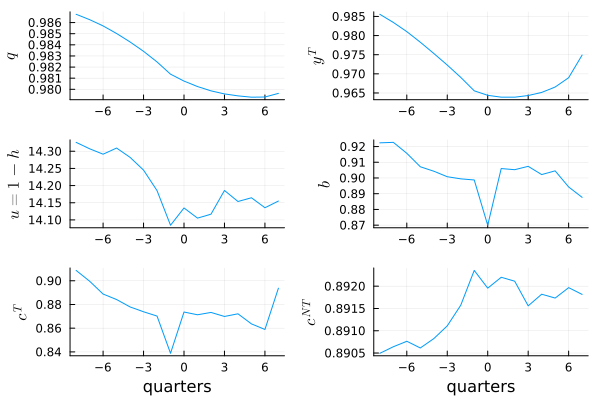

In [20]:
# Graph of simulations results
x = [-8:1:7]
plot_q = plot(x, qₛ, ylabel = L"q")
plot_yt = plot(x, yₛᵀ, ylabel = L"y^{T}")
plot_u = plot(x, (1 .- hₛᴾ)*100, ylabel = L"u=1-h")
plot_b = plot(x, bₛᴾ, ylabel = L"b")
plot_cT = plot(x, cₛᵀᴾ, xlabel = "quarters", ylabel = L"c^{T}")
plot_cN = plot(x, cₛᴺᴾ, xlabel = "quarters", ylabel = L"c^{NT}")

plot(plot_q, plot_yt, plot_u, plot_b, plot_cT, plot_cN,
     layout = (3,2), legend = false)


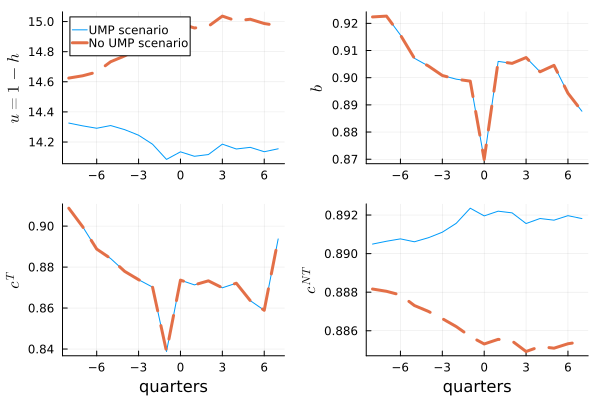

In [21]:
plot_u = plot(x, (1 .- hₛᴾ)*100, ylabel = L"u=1-h", 
              label = "UMP scenario")
plot_b = plot(x, bₛᴾ, ylabel = L"b", legend = false)
plot_cT = plot(x, cₛᵀᴾ, xlabel = "quarters", ylabel = L"c^{T}", legend = false)
plot_cN = plot(x, cₛᴺᴾ, xlabel = "quarters", ylabel = L"c^{NT}", legend = false)

plot_uP = plot!(plot_u, x, (1 .- hₛ)*100, ls = :dash, lw = 3,
                label = "No UMP scenario")
plot_bP = plot!(plot_b, x, bₛ, ls = :dash, lw = 3, legend = false)
plot_cTP = plot!(plot_cT, x, cₛᵀ, ls = :dash, lw = 3, legend = false)
plot_cNP = plot!(plot_cN, x, cₛᴺ, ls = :dash, lw = 3, legend = false)

plot(plot_uP, plot_bP, plot_cTP, plot_cNP, layout = (2,2))

In [39]:
q_shock2 = findall(q -> (q/mod_spain.qbar) < 1 && 
            abs(q/mod_spain.qbar-1) ≥ mod_spain.threshold*2, 
            sim_spain.q_sim)

sov_shock2 = intersect(q_shock2,yᵀ_shock)

sov_crisis0 = []
for (i, q) in enumerate(sov_shock2[1:end-8])
    aux = sov_shock2[i:i+7]
    if aux[end] - aux[1] == 7
        push!(sov_crisis0, aux[1]-7:aux[1]+8)
    end
end

In [42]:
size(sov_crisis0)

(216,)

In [40]:
b_sov_crises0 = zeros(length(sov_crisis0),sum(abs.(q_window)))
h_sov_crises0 = similar(b_sov_crises0)
cᵀ_sov_crises0 = similar(b_sov_crises0) 
cᴺ_sov_crises0 = similar(b_sov_crises0)
c_sov_crises0 = similar(b_sov_crises0) 
q_sov_crises0 = similar(b_sov_crises0)
yᵀ_sov_crises0 = similar(b_sov_crises0)
b_sov_crises_P0 = similar(b_sov_crises0)
h_sov_crises_P0 = similar(b_sov_crises0)
cᵀ_sov_crises_P0 = similar(b_sov_crises0) 
cᴺ_sov_crises_P0 = similar(b_sov_crises0)
c_sov_crises_P0 = similar(b_sov_crises0)

for iˢ in 1:length(sov_crisis0)
    b_sov_crises0[iˢ,:] = sim_spain.b_sim[sov_crisis0[iˢ]]
    h_sov_crises0[iˢ,:] = sim_spain.h_sim[sov_crisis0[iˢ]]
    cᵀ_sov_crises0[iˢ,:] = sim_spain.cᵀ_sim[sov_crisis0[iˢ]]
    cᴺ_sov_crises0[iˢ,:] = sim_spain.cᴺ_sim[sov_crisis0[iˢ]]
    c_sov_crises0[iˢ,:] = sim_spain.c_sim[sov_crisis0[iˢ]]
    q_sov_crises0[iˢ,:] = sim_spain.q_sim[sov_crisis0[iˢ]]
    yᵀ_sov_crises0[iˢ,:] = sim_spain.yᵀ_sim[sov_crisis0[iˢ]]
    b_sov_crises_P0[iˢ,:] = sim_spain.b_sim_P[sov_crisis0[iˢ]]
    h_sov_crises_P0[iˢ,:] = sim_spain.h_sim_P[sov_crisis0[iˢ]]
    cᵀ_sov_crises_P0[iˢ,:] = sim_spain.cᵀ_sim_P[sov_crisis0[iˢ]]
    cᴺ_sov_crises_P0[iˢ,:] = sim_spain.cᴺ_sim_P[sov_crisis0[iˢ]]
    c_sov_crises_P0[iˢ,:] = sim_spain.c_sim_P[sov_crisis0[iˢ]]
end

bₛ = vec(mean(b_sov_crises0, dims = 1))
hₛ = vec(mean(h_sov_crises0, dims = 1))
cₛᵀ = vec(mean(cᵀ_sov_crises0, dims = 1))
cₛᴺ = vec(mean(cᴺ_sov_crises0, dims = 1))
cₛ = vec(mean(c_sov_crises0, dims = 1))
qₛ = vec(mean(q_sov_crises0, dims = 1))
yₛᵀ = vec(mean(yᵀ_sov_crises0, dims = 1))
bₛᴾ = vec(mean(b_sov_crises_P0, dims = 1))
hₛᴾ = vec(mean(h_sov_crises_P0, dims = 1))
cₛᵀᴾ = vec(mean(cᵀ_sov_crises_P0, dims = 1))
cₛᴺᴾ = vec(mean(cᴺ_sov_crises_P0, dims = 1))
cₛᴾ = vec(mean(c_sov_crises_P0, dims = 1));

In [41]:
# Graph of simulations results
x = [-8:1:7]
plot_q = plot(x, qₛ, ylabel = L"q")
plot_yt = plot(x, yₛᵀ, ylabel = L"y^{T}")
plot_u = plot(x, (1 .- hₛᴾ)*100, ylabel = L"u=100(1-h)")
plot_b = plot(x, bₛᴾ, ylabel = L"b")
plot_cT = plot(x, cₛᵀᴾ, xlabel = "quarters", ylabel = L"c^{T}")
plot_cN = plot(x, cₛᴺᴾ, xlabel = "quarters", ylabel = L"c^{NT}")

plot(plot_q, plot_yt, plot_u, plot_b, plot_cT, plot_cN,
     layout = (3,2), legend = false)
savefig("ident_sov_crisis_1.pdf")

"/Users/nes/Google Drive/PhD_Thesis/Second Paper/ident_sov_crisis_1.pdf"

In [50]:
plot_u = plot(x, (1 .- hₛᴾ)*100, ylabel = L"u=100(1-h)", 
              label = "UMP scenario", ylims = (14.0, 16.0), legend = :topleft)
plot_b = plot(x, bₛᴾ, ylabel = L"b", legend = false)
plot_cT = plot(x, cₛᵀᴾ, xlabel = "quarters", ylabel = L"c^{T}", legend = false)
plot_cN = plot(x, cₛᴺᴾ, xlabel = "quarters", ylabel = L"c^{NT}", legend = false)

plot_uP = plot!(plot_u, x, (1 .- hₛ)*100, ls = :dash, lw = 3,
                label = "No UMP scenario")
plot_bP = plot!(plot_b, x, bₛ, ls = :dash, lw = 3, legend = false)
plot_cTP = plot!(plot_cT, x, cₛᵀ, ls = :dash, lw = 3, legend = false)
plot_cNP = plot!(plot_cN, x, cₛᴺ, ls = :dash, lw = 3, legend = false)

plot(plot_uP, plot_bP, plot_cTP, plot_cNP, layout = (2,2))
savefig("couterfactual_UMP.pdf")

"/Users/nes/Google Drive/PhD_Thesis/Second Paper/couterfactual_UMP.pdf"

In [32]:
q_shock2 = findall(q -> (q/mod_spain.qbar) < 1 && 
            abs(q/mod_spain.qbar-1) ≥ mod_spain.threshold*2, 
            sim_spain.q_sim)

sov_crisis0 = []
for (i, q) in enumerate(q_shock2[1:end-8])
    aux = q_shock2[i:i+7]
    if aux[end] - aux[1] == 7
        push!(sov_crisis0, aux[1]-7:aux[1]+8)
    end
end

In [33]:
b_sov_crises0 = zeros(length(sov_crisis0),sum(abs.(q_window)))
h_sov_crises0 = similar(b_sov_crises0)
cᵀ_sov_crises0 = similar(b_sov_crises0) 
cᴺ_sov_crises0 = similar(b_sov_crises0)
c_sov_crises0 = similar(b_sov_crises0) 
q_sov_crises0 = similar(b_sov_crises0)
yᵀ_sov_crises0 = similar(b_sov_crises0)
b_sov_crises_P0 = similar(b_sov_crises0)
h_sov_crises_P0 = similar(b_sov_crises0)
cᵀ_sov_crises_P0 = similar(b_sov_crises0) 
cᴺ_sov_crises_P0 = similar(b_sov_crises0)
c_sov_crises_P0 = similar(b_sov_crises0)

for iˢ in 1:length(sov_crisis0)
    b_sov_crises0[iˢ,:] = sim_spain.b_sim[sov_crisis0[iˢ]]
    h_sov_crises0[iˢ,:] = sim_spain.h_sim[sov_crisis0[iˢ]]
    cᵀ_sov_crises0[iˢ,:] = sim_spain.cᵀ_sim[sov_crisis0[iˢ]]
    cᴺ_sov_crises0[iˢ,:] = sim_spain.cᴺ_sim[sov_crisis0[iˢ]]
    c_sov_crises0[iˢ,:] = sim_spain.c_sim[sov_crisis0[iˢ]]
    q_sov_crises0[iˢ,:] = sim_spain.q_sim[sov_crisis0[iˢ]]
    yᵀ_sov_crises0[iˢ,:] = sim_spain.yᵀ_sim[sov_crisis0[iˢ]]
    b_sov_crises_P0[iˢ,:] = sim_spain.b_sim_P[sov_crisis0[iˢ]]
    h_sov_crises_P0[iˢ,:] = sim_spain.h_sim_P[sov_crisis0[iˢ]]
    cᵀ_sov_crises_P0[iˢ,:] = sim_spain.cᵀ_sim_P[sov_crisis0[iˢ]]
    cᴺ_sov_crises_P0[iˢ,:] = sim_spain.cᴺ_sim_P[sov_crisis0[iˢ]]
    c_sov_crises_P0[iˢ,:] = sim_spain.c_sim_P[sov_crisis0[iˢ]]
end

bₛ = vec(mean(b_sov_crises0, dims = 1))
hₛ = vec(mean(h_sov_crises0, dims = 1))
cₛᵀ = vec(mean(cᵀ_sov_crises0, dims = 1))
cₛᴺ = vec(mean(cᴺ_sov_crises0, dims = 1))
cₛ = vec(mean(c_sov_crises0, dims = 1))
qₛ = vec(mean(q_sov_crises0, dims = 1))
yₛᵀ = vec(mean(yᵀ_sov_crises0, dims = 1))
bₛᴾ = vec(mean(b_sov_crises_P0, dims = 1))
hₛᴾ = vec(mean(h_sov_crises_P0, dims = 1))
cₛᵀᴾ = vec(mean(cᵀ_sov_crises_P0, dims = 1))
cₛᴺᴾ = vec(mean(cᴺ_sov_crises_P0, dims = 1))
cₛᴾ = vec(mean(c_sov_crises_P0, dims = 1));

In [37]:
x = [-8:1:7]
plot_q = plot(x, qₛ, ylabel = L"q")
plot_yt = plot(x, yₛᵀ, ylabel = L"y^{T}")
plot_u = plot(x, (1 .- hₛᴾ)*100, ylabel = L"u=100(1-h)")
plot_b = plot(x, bₛᴾ, ylabel = L"b")
plot_cT = plot(x, cₛᵀᴾ, xlabel = "quarters", ylabel = L"c^{T}")
plot_cN = plot(x, cₛᴺᴾ, xlabel = "quarters", ylabel = L"c^{NT}")

plot(plot_q, plot_yt, plot_u, plot_b, plot_cT, plot_cN,
     layout = (3,2), legend = false)
savefig("ident_sov_crisis_0.pdf")

"/Users/nes/Google Drive/PhD_Thesis/Second Paper/ident_sov_crisis_0.pdf"

In [38]:
size(sov_crisis0)

(1423,)

In [27]:
norm(mod_spain.index_policy_b⁺ᴾ)

60415.298261284785

In [28]:
size(mod_spain.Π)

(469, 469)